# Week 5 — From images to features: atom columns, local descriptors & tree ensembles

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg  
**Author:** Prof. Dr. Philipp Pelz  
**Prerequisites:** Week 1 (NumPy, matplotlib) · Week 2 (Poisson noise) · Week 4 (validation, `GroupKFold`)  
**Time budget:** ~90 minutes for a beginner working steadily · whole notebook runs in a few minutes on a CPU

## What you will do

1. **Simulate HAADF-STEM images** of a square lattice with two kinds of point defects:
   *vacancy-containing columns* (dimmer) and *heavier substitutional columns* (brighter). Every image has its own
   probe current, background and dose — just like a real session.
2. **Find the atom columns**: local-maximum peak finding on a smoothed image, then **2-D Gaussian refinement** for sub-pixel positions.
3. Turn every column into a row of a **feature table**: raw intensities *and* **local-environment descriptors**
   (relative intensity, neighbour distances, bond angles, 2-D radial symmetry functions — the 2-D cousin of ACSF/SOAP).
4. Climb the **baseline ladder** (majority → logistic regression → random forest → gradient boosting) for a
   3-class *defect classifier*, always with **`GroupKFold` by image**.
5. Ask the model *what it uses*: **impurity (MDI) vs permutation importance**, and the **correlated-feature pitfall**.
6. *(Optional)* SHAP values — only if the `shap` package is installed; the notebook runs without it.

> **Reading guide.** Cells marked `# (try this yourself)` are the exercise lines — attempt them before looking at the solution markdown underneath.

In [1]:
# --- Cell 1: Install and import ---
# On Colab the missing packages are installed; locally we assume the course environment.
import os, sys, subprocess
os.environ.setdefault("OMP_NUM_THREADS", "2")   # keeps tree ensembles fast on shared machines
if "google.colab" in sys.modules:          # only install on Colab — never touch a local environment
    subprocess.run([sys.executable, "-m", "pip", "install", "scikit-image", "scikit-learn", "--quiet"],
                   check=False)

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.optimize import curve_fit
from scipy.spatial import cKDTree
from skimage.feature import peak_local_max
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CCOL = ["#2a78d6", "#eb6834", "#1baf7a"]   # host / vacancy / substitution
print("Imports OK — NumPy", np.__version__)

Imports OK — NumPy 1.26.4


## Part 1 — Simulate a HAADF-STEM image with point defects

HAADF intensity scales roughly as $I \propto Z^{\approx 1.7}$ per atom and with the number of atoms in the column.
We model three column classes on a square lattice (spacing $a = 12$ px):

| class | relative intensity | local strain |
|---|---|---|
| host | 1.00 | — |
| vacancy-containing column | 0.75 (fewer atoms) | neighbours relax **inwards** |
| substitution (heavier $Z$) | 1.35 | neighbours pushed **outwards** |

Nuisances that change **from image to image** (and make life hard for naive features):
probe current / detector gain (a global intensity scale 0.6–1.4), background level and gradient, dose (25–60 counts at a host peak),
and a 10 % column-to-column intensity scatter (thickness, channelling). Finally Poisson noise (Week 2).

In [2]:
A = 12.0          # lattice spacing (px)
N_PIX = 240       # image size (px)
SIG = 2.0         # column width (px)
CLASSES = ["host", "vacancy", "substitution"]
REL_I = np.array([1.0, 0.75, 1.35])   # column intensity relative to host (~Z^1.7 / partial occupancy)


def simulate_haadf(rng, n_pix=N_PIX, a=A):
    """Simulate one HAADF-STEM image of a square lattice with vacancy/substitution columns."""
    n = int(n_pix // a)
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    pos = np.stack([ii.ravel() * a + a / 2, jj.ravel() * a + a / 2], 1).astype(float)
    p_vac, p_sub = rng.uniform(0.03, 0.10, 2)            # defect content varies per image
    cls = rng.choice(3, size=len(pos), p=[1 - p_vac - p_sub, p_vac, p_sub])
    # local relaxation: substitution pushes neighbours out, vacancy pulls them in
    disp = np.zeros_like(pos)
    tree = cKDTree(pos)
    for k in np.where(cls > 0)[0]:
        for j in tree.query_ball_point(pos[k], r=1.5 * a):
            if j == k:
                continue
            v = pos[j] - pos[k]
            r = np.linalg.norm(v)
            amp = 0.8 if cls[k] == 2 else -0.6
            disp[j] += amp * (a / r) ** 2 * v / r
    pos_true = pos + disp + rng.normal(0, 0.12, pos.shape)
    # image-level nuisance: probe current / detector gain, background, dose
    scale = rng.uniform(0.6, 1.4)
    inten = scale * REL_I[cls] * (1 + 0.10 * rng.normal(size=len(pos)))
    sig = SIG * (1 + 0.04 * rng.normal(size=len(pos)))
    img = np.zeros((n_pix, n_pix))
    w = 8
    for (r0, c0), I0, s in zip(pos_true, inten, sig):
        ri, ci = int(round(r0)), int(round(c0))
        rs, cs = slice(max(ri - w, 0), min(ri + w + 1, n_pix)), slice(max(ci - w, 0), min(ci + w + 1, n_pix))
        R, C = np.mgrid[rs, cs]
        img[rs, cs] += I0 * np.exp(-((R - r0) ** 2 + (C - c0) ** 2) / (2 * s ** 2))
    yy, xx = np.mgrid[0:n_pix, 0:n_pix] / n_pix
    bg = scale * (rng.uniform(0.05, 0.25) + rng.uniform(-0.08, 0.08) * xx + rng.uniform(-0.08, 0.08) * yy)
    dose = rng.uniform(25, 60)                           # counts at a host-column peak
    img = rng.poisson(np.clip(img + bg, 0, None) * dose) / dose
    return img, pos_true, cls

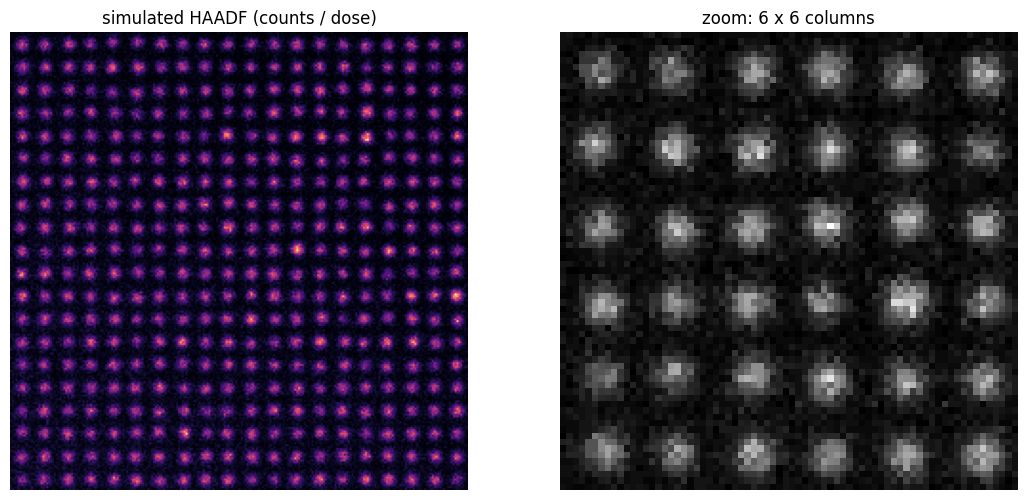

columns per class: {'host': 339, 'vacancy': 36, 'substitution': 25}


In [3]:
# --- Cell 3: look at one image ---
rng = np.random.default_rng(0)
img0, pos0, cls0 = simulate_haadf(rng)
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(img0, cmap="magma"); ax[0].set_title("simulated HAADF (counts / dose)")
ax[1].imshow(img0[60:132, 60:132], cmap="gray"); ax[1].set_title("zoom: 6 x 6 columns")
for a in ax: a.axis("off")
plt.show()
print("columns per class:", dict(zip(CLASSES, np.bincount(cls0, minlength=3))))

## Part 2 — Atom-column finding: peaks → 2-D Gaussian refinement

The classical pipeline (as in *Atomap*, Nord et al. 2017):

1. **Smooth** with a small Gaussian (σ ≈ 1.5 px) to suppress Poisson noise — a matched-filter idea.
2. **Local maxima** with a minimum separation (`min_distance ≈ 0.4 a`) and an intensity threshold → integer-pixel positions.
3. **Refine** each column by least-squares fitting $I(\mathbf{r}) = A\,e^{-|\mathbf{r}-\mathbf{r}_0|^2/2\sigma^2} + b$ in a small window.
   The fit returns sub-pixel position $\mathbf{r}_0$, amplitude $A$, width $\sigma$ and local background $b$ — our first features.

Least squares = Gaussian noise assumption (Week 2). At very low dose a Poisson likelihood would be the principled choice.

In [4]:
def _gauss2d(rc, amp, r0, c0, s, b):
    R, C = rc
    return (amp * np.exp(-((R - r0) ** 2 + (C - c0) ** 2) / (2 * s ** 2)) + b).ravel()


def find_columns(img, a=A, w=4):
    """Peak finding on a smoothed image, then 2-D Gaussian refinement per column."""
    sm = ndimage.gaussian_filter(img, 1.5)
    base = np.median(sm)
    thr = base + 0.3 * (np.percentile(sm, 99.5) - base)
    peaks = peak_local_max(sm, min_distance=int(0.4 * a), threshold_abs=thr, exclude_border=w)
    out = []
    for r, c in peaks:
        win = img[r - w:r + w + 1, c - w:c + w + 1]
        R, C = np.mgrid[r - w:r + w + 1, c - w:c + w + 1]
        p0 = [win.max() - win.min(), r, c, SIG, win.min()]
        try:
            p, _ = curve_fit(_gauss2d, (R, C), win.ravel(), p0=p0, maxfev=2000)
            if abs(p[1] - r) > 2 or abs(p[2] - c) > 2 or not (0.5 < abs(p[3]) < 5):
                raise RuntimeError
        except Exception:
            p = p0
        amp, r0, c0, s, b = p
        integ = (win - b).sum()
        out.append([r0, c0, amp, abs(s), b, integ])
    return np.array(out)   # columns: row, col, amp, sigma, bg, integrated intensity

true columns: 400   detected: 400   matched (< a/3): 400
mean position error after Gaussian refinement: 0.138 px


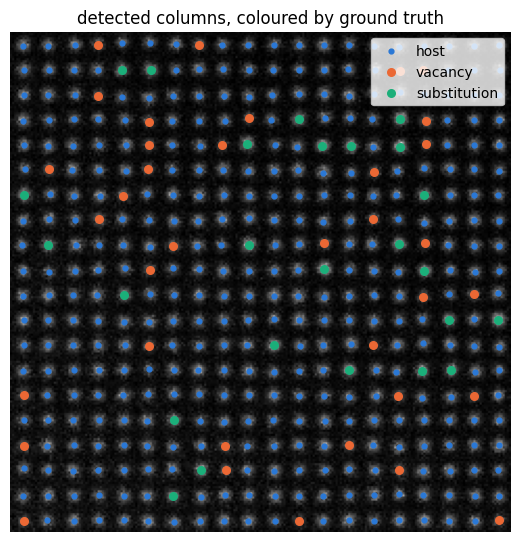

In [5]:
# --- Cell 5: run the finder and measure accuracy against ground truth ---
cols0 = find_columns(img0)
d0, idx0 = cKDTree(pos0).query(cols0[:, :2])
print(f"true columns: {len(pos0)}   detected: {len(cols0)}   matched (< a/3): {(d0 < A/3).sum()}")
print(f"mean position error after Gaussian refinement: {d0.mean():.3f} px")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(img0, cmap="gray")
lab0 = cls0[idx0]
for c in range(3):
    m = lab0 == c
    ax.scatter(cols0[m, 1], cols0[m, 0], s=12 if c == 0 else 30, color=CCOL[c], label=CLASSES[c])
ax.legend(loc="upper right"); ax.axis("off"); ax.set_title("detected columns, coloured by ground truth")
plt.show()

## Part 3 — From columns to a feature table: local-environment descriptors

A column's **absolute** amplitude depends on the probe current of *that* image — useless on a new image.
Physics tells us what should matter instead: how the column compares with its **neighbours**, and how the neighbours
are **displaced** by the defect. A good descriptor must be

* **translation invariant** (use $\mathbf{r}_j-\mathbf{r}_i$, never $\mathbf{r}_i$),
* **rotation invariant** (distances, angles — not raw $\Delta x, \Delta y$),
* **permutation invariant** (sums / means / sorted lists over neighbours — never "neighbour #1, #2, …"),
* **invariant to image-level nuisances** (ratios such as $I_\mathrm{rel}$ cancel the probe-current scale).

| feature | meaning | invariant to image scale? |
|---|---|---|
| `amp`, `I_int` | fitted peak amplitude, integrated intensity | no |
| `sigma`, `bg_local` | fitted width, local background | — |
| `x_pos` | column x-position — a deliberate **nuisance** feature (physically meaningless) | — |
| `I_rel`, `amp_rel` | intensity ÷ median of first-shell neighbours | **yes** |
| `n_nb`, `d_mean`, `d_std` | neighbour count, mean / std of bond length | yes |
| `ang_std` | spread of angular gaps between neighbours (0 for a perfect square) | yes |
| `G_0.9a`, `G_1.0a`, `G_1.1a` | 2-D radial symmetry functions $G_i(R_s)=\sum_j e^{-\eta(r_{ij}-R_s)^2}$ (ACSF radial term) | yes |

In [6]:
FEATURES = ["amp", "I_int", "sigma", "bg_local", "x_pos",
            "I_rel", "amp_rel", "n_nb", "d_mean", "d_std", "ang_std", "G_0.9a", "G_1.0a", "G_1.1a"]
RAW_FEATURES = FEATURES[:5]


def local_descriptors(cols, a=A, n_pix=N_PIX):
    """Local-environment descriptors for every detected column (2-D ACSF analogue)."""
    xy = cols[:, :2]
    tree = cKDTree(xy)
    feats = []
    for k in range(len(cols)):
        nb = [j for j in tree.query_ball_point(xy[k], r=1.25 * a) if j != k]
        v = xy[nb] - xy[k]
        d = np.linalg.norm(v, axis=1)
        if len(nb) >= 2:
            ang = np.sort(np.arctan2(v[:, 0], v[:, 1]))
            gaps = np.diff(np.r_[ang, ang[0] + 2 * np.pi])
            ang_std = np.degrees(gaps.std())
        else:
            ang_std = 90.0
        I_rel = cols[k, 5] / np.median(cols[nb, 5]) if len(nb) else 1.0     # integrated, relative
        amp_rel = cols[k, 2] / np.median(cols[nb, 2]) if len(nb) else 1.0   # peak height, relative
        # 2-D radial symmetry functions G(R_s) = sum_j exp(-eta (r_ij - R_s)^2) over a wider shell
        nb2 = [j for j in tree.query_ball_point(xy[k], r=1.6 * a) if j != k]
        d2 = np.linalg.norm(xy[nb2] - xy[k], axis=1)
        eta = 1.0 / (0.05 * a) ** 2
        G = [np.exp(-eta * (d2 - Rs * a) ** 2).sum() for Rs in (0.9, 1.0, 1.1)]
        feats.append([cols[k, 2], cols[k, 5], cols[k, 3], cols[k, 4], cols[k, 1],
                      I_rel, amp_rel, len(nb), d.mean() if len(nb) else a, d.std() if len(nb) else 0.0,
                      ang_std, *G])
    return np.array(feats)


def build_dataset(n_images=12, seed=0):
    rng = np.random.default_rng(seed)
    X, y, g, stats = [], [], [], []
    for im in range(n_images):
        img, pos_true, cls = simulate_haadf(rng)
        cols = find_columns(img)
        F = local_descriptors(cols)
        d, idx = cKDTree(pos_true).query(cols[:, :2])
        ok = d < A / 3
        inner = np.all((cols[:, :2] > A) & (cols[:, :2] < N_PIX - A), axis=1)
        keep = ok & inner
        X.append(F[keep]); y.append(cls[idx[keep]]); g.append(np.full(keep.sum(), im))
        stats.append(dict(n_true=len(pos_true), n_found=len(cols), n_matched=ok.sum(),
                          pos_err=d[ok].mean()))
    return np.vstack(X), np.concatenate(y), np.concatenate(g), stats

In [7]:
# --- Cell 7: build the dataset (12 images ≈ 3 900 columns, ~10 s) ---
X, y, groups, stats = build_dataset(n_images=12, seed=0)
print("feature matrix X:", X.shape, "  classes:", dict(zip(CLASSES, np.bincount(y))))
print("mean position error over all images: %.3f px" % np.mean([s["pos_err"] for s in stats]))
print("columns per image:", np.bincount(groups))

feature matrix X: (3888, 14)   classes: {'host': 3337, 'vacancy': 286, 'substitution': 265}
mean position error over all images: 0.128 px
columns per image: [324 324 324 324 324 324 324 324 324 324 324 324]


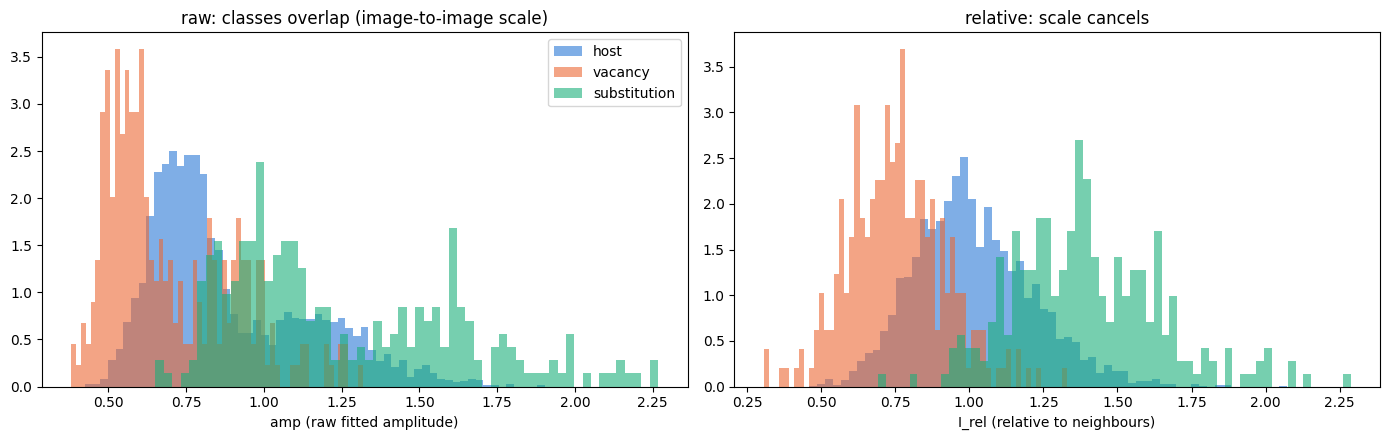

In [8]:
# --- Cell 8: does a raw feature separate the classes?  Does a local descriptor? ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for c in range(3):
    m = y == c
    ax[0].hist(X[m, FEATURES.index("amp")], 60, alpha=0.6, density=True, color=CCOL[c], label=CLASSES[c])
    ax[1].hist(X[m, FEATURES.index("I_rel")], 60, alpha=0.6, density=True, color=CCOL[c], label=CLASSES[c])
ax[0].set_xlabel("amp (raw fitted amplitude)"); ax[0].set_title("raw: classes overlap (image-to-image scale)")
ax[1].set_xlabel("I_rel (relative to neighbours)"); ax[1].set_title("relative: scale cancels")
ax[0].legend(); plt.tight_layout(); plt.show()

## Part 4 — The baseline ladder, evaluated honestly

Rules of the game (Week 4):

* **Groups = images.** Columns of one image share probe current, background and dose. A random split lets the model
  learn "which image is this?" — leakage. We use `GroupKFold(n_splits=4)` with `groups=image_id`.
* **Metric = balanced accuracy.** 86 % of columns are host; a model that always says "host" gets 86 % plain accuracy
  but only 1/3 balanced accuracy.
* **Climb the ladder:** majority → linear → tree ensembles. Each rung must beat the previous one on the *honest* score to be worth its complexity.

In [9]:
# --- Cell 9: baseline ladder with GroupKFold by image ---
gkf = GroupKFold(n_splits=4)
RAW = [FEATURES.index(f) for f in RAW_FEATURES]
ALL = list(range(X.shape[1]))

ladder = {
    "majority":       DummyClassifier(strategy="most_frequent"),
    "logistic":       make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
    "random forest":  RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                             class_weight="balanced_subsample", n_jobs=2, random_state=0),
    "grad. boosting": HistGradientBoostingClassifier(max_iter=150, class_weight="balanced", random_state=0),
}
scores = {}
for name, model in ladder.items():
    for fs_name, cols in [("raw", RAW), ("all", ALL)]:
        s = cross_val_score(model, X[:, cols], y, cv=gkf, groups=groups, scoring="balanced_accuracy")
        scores[(name, fs_name)] = s.mean()
        print(f"{name:15s} | {fs_name:3s} features | balanced acc. = {s.mean():.3f} ± {s.std():.3f}")

majority        | raw features | balanced acc. = 0.333 ± 0.000
majority        | all features | balanced acc. = 0.333 ± 0.000
logistic        | raw features | balanced acc. = 0.526 ± 0.091
logistic        | all features | balanced acc. = 0.975 ± 0.011


random forest   | raw features | balanced acc. = 0.481 ± 0.060


random forest   | all features | balanced acc. = 0.939 ± 0.026


grad. boosting  | raw features | balanced acc. = 0.472 ± 0.054


grad. boosting  | all features | balanced acc. = 0.949 ± 0.006


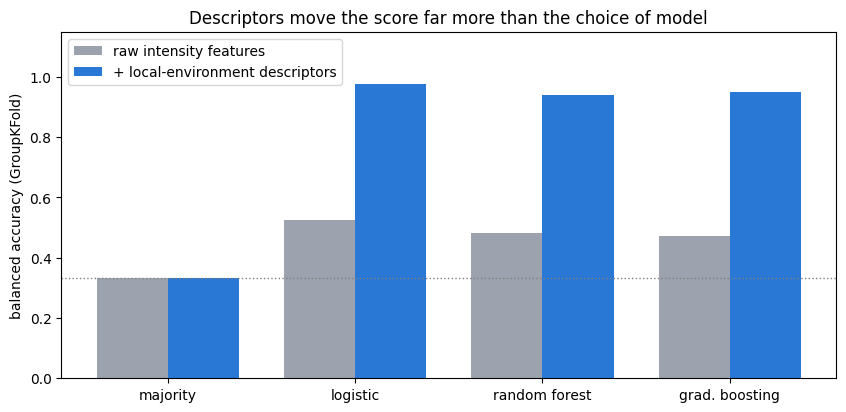

In [10]:
# --- Cell 10: plot the ladder ---
names = list(ladder)
xp = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(xp - w/2, [scores[(n, "raw")] for n in names], w, color="#9ca3af", label="raw intensity features")
ax.bar(xp + w/2, [scores[(n, "all")] for n in names], w, color=CCOL[0], label="+ local-environment descriptors")
ax.axhline(1/3, color="gray", ls=":", lw=1)
ax.set_xticks(xp); ax.set_xticklabels(names); ax.set_ylim(0, 1.15)
ax.set_ylabel("balanced accuracy (GroupKFold)"); ax.legend(loc="upper left")
ax.set_title("Descriptors move the score far more than the choice of model")
plt.show()

**Read the plot carefully — it is the main lesson of the week.**

* Going from raw to local descriptors lifts *every* model from ≈ 0.5 to > 0.9. **Feature design did the heavy lifting.**
* With good, physically designed descriptors the classes are almost *linearly* separable, so logistic regression is
  as good as (here: slightly better than) the tree ensembles. That is not a failure of trees — it is the reason the
  ladder exists: **you only keep a more complex model if it beats the simpler one on the honest score.**
* Trees shine when the relation is non-linear, thresholded or full of interactions and features are heterogeneous — typical of
  process-parameter / composition tables (Grinsztajn et al. 2022).

## Part 5 — Leakage check: random KFold vs GroupKFold

The raw features include `bg_local`, whose level is set per image. With a random split, the model can recognise the
image (and its defect fraction) from the background. With `GroupKFold` it cannot.

In [11]:
# --- Cell 11: random vs grouped CV on the raw features ---
kf = KFold(n_splits=4, shuffle=True, random_state=0)
leak = {}
for name in ["logistic", "random forest"]:
    m = ladder[name]
    r_rand = cross_val_score(m, X[:, RAW], y, cv=kf, scoring="balanced_accuracy").mean()
    r_grp  = cross_val_score(m, X[:, RAW], y, cv=gkf, groups=groups, scoring="balanced_accuracy").mean()
    leak[name] = (r_rand, r_grp)
    print(f"{name:14s} raw features: random KFold {r_rand:.3f}  vs  GroupKFold {r_grp:.3f}  (gap {r_rand - r_grp:+.3f})")

logistic       raw features: random KFold 0.621  vs  GroupKFold 0.526  (gap +0.096)


random forest  raw features: random KFold 0.564  vs  GroupKFold 0.481  (gap +0.083)


## Part 6 — What does the forest use? MDI vs permutation importance

* **MDI (mean decrease in impurity)** = `feature_importances_`: free, but computed on the **training** data and biased towards
  continuous / high-cardinality features. Even pure noise gets a non-zero score.
* **Permutation importance**: shuffle one column of the **held-out** data, measure the drop in score. Model-agnostic and honest —
  but it measures *what this model relies on*, not what is physically causal.

We train on 3 folds of images and evaluate importances on the held-out images.

held-out balanced accuracy: 0.855


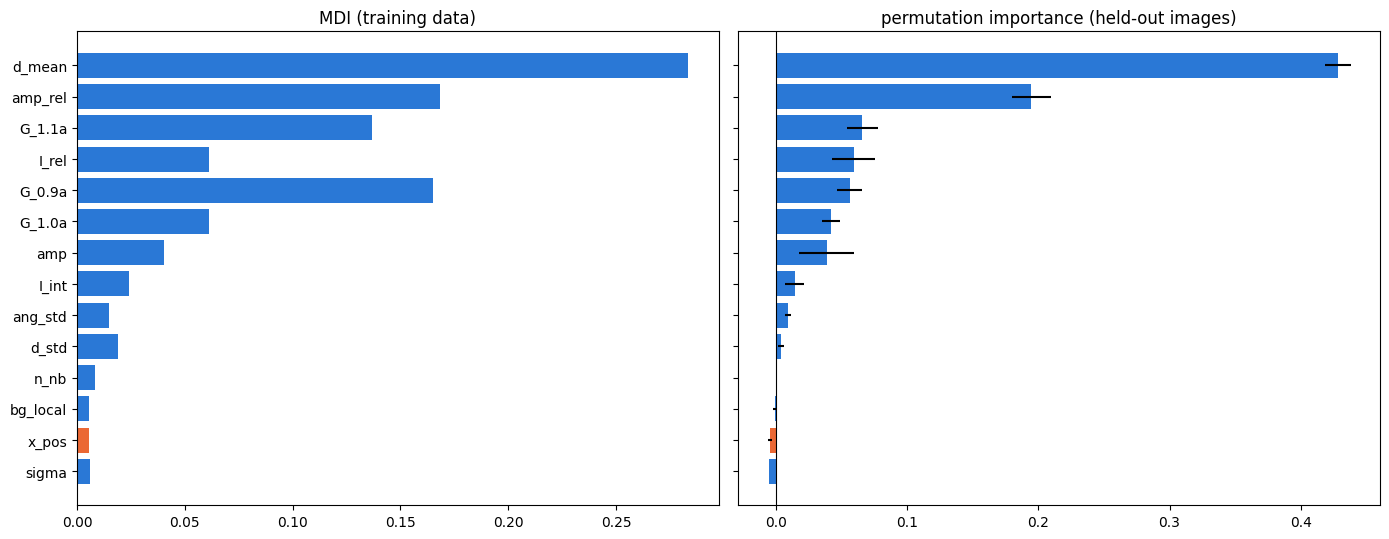

x_pos    : MDI = 0.0054   permutation = -0.0048
sigma    : MDI = 0.0061   permutation = -0.0054
bg_local : MDI = 0.0055   permutation = -0.0005


In [12]:
# --- Cell 12: MDI vs permutation importance on held-out images ---
tr, te = next(gkf.split(X, y, groups))
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample", n_jobs=2, random_state=0)
rf.fit(X[tr], y[tr])
base_score = balanced_accuracy_score(y[te], rf.predict(X[te]))
print(f"held-out balanced accuracy: {base_score:.3f}")

mdi = rf.feature_importances_
pi = permutation_importance(rf, X[te], y[te], scoring="balanced_accuracy", n_repeats=10, random_state=0)
order = np.argsort(pi.importances_mean)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
colr = [CCOL[1] if FEATURES[i] == "x_pos" else CCOL[0] for i in order]
ax[0].barh(range(len(order)), mdi[order], color=colr); ax[0].set_title("MDI (training data)")
ax[1].barh(range(len(order)), pi.importances_mean[order], xerr=pi.importances_std[order], color=colr)
ax[1].set_title("permutation importance (held-out images)"); ax[1].axvline(0, color="k", lw=0.8)
ax[0].set_yticks(range(len(order))); ax[0].set_yticklabels([FEATURES[i] for i in order])
plt.tight_layout(); plt.show()
for f in ["x_pos", "sigma", "bg_local"]:
    i = FEATURES.index(f)
    print(f"{f:9s}: MDI = {mdi[i]:.4f}   permutation = {pi.importances_mean[i]:+.4f}")

## Part 7 — The correlated-feature pitfall

Suppose we also measured the relative intensity with a slightly smaller integration window, `I_rel_r3`.
It is almost a copy of `I_rel`. When one of them is shuffled, the forest simply uses the other — so **each looks
unimportant, although together they matter.** The fix: permute *correlated groups* together (or cluster features first).

In [13]:
# --- Cell 13: add a near-duplicate of I_rel and compare importances ---
rng_dup = np.random.default_rng(1)
iI = FEATURES.index("I_rel")
X_dup = np.c_[X, X[:, iI] * (1 + 0.02 * rng_dup.normal(size=len(X)))]    # "I_rel_r3"
rf_dup = clone(rf).fit(X_dup[tr], y[tr])
pi_dup = permutation_importance(rf_dup, X_dup[te], y[te], scoring="balanced_accuracy",
                                n_repeats=10, random_state=0)
print(f"I_rel importance, no duplicate      : {pi.importances_mean[iI]:.3f}")
print(f"I_rel importance, with duplicate    : {pi_dup.importances_mean[iI]:.3f}")
print(f"I_rel_r3 (the duplicate) importance : {pi_dup.importances_mean[-1]:.3f}")

I_rel importance, no duplicate      : 0.059
I_rel importance, with duplicate    : 0.046
I_rel_r3 (the duplicate) importance : 0.053


## Exercise 1 — Grouped permutation importance

Write a function `grouped_permutation_importance(model, X_te, y_te, cols, n_repeats=10)` that shuffles **all columns in
`cols` with the same row permutation** and returns the mean drop in balanced accuracy.

1. Apply it to the pair `[I_rel, I_rel_r3]` of `rf_dup`. It should be clearly larger than either single importance.
2. Apply it to the geometry group `["d_mean", "G_0.9a", "G_1.0a", "G_1.1a"]` of `rf` and compare with the **sum** of the single-feature
   importances. Why can the sum be *larger* than the group? *(Hint: what does shuffling `d_mean` alone do to the consistency between `d_mean` and the $G$ features?)*

In [14]:
# --- Cell 14: Exercise 1 (working version with try-this markers) ---
def grouped_permutation_importance(model, X_te, y_te, cols, n_repeats=10, seed=0):
    rng_g = np.random.default_rng(seed)
    base = balanced_accuracy_score(y_te, model.predict(X_te))
    drops = []
    for _ in range(n_repeats):
        Xp = X_te.copy()
        perm = rng_g.permutation(len(X_te))          # (try this yourself) ONE permutation for the whole group
        Xp[:, cols] = X_te[perm][:, cols]            # (try this yourself) apply it to all columns in `cols`
        drops.append(base - balanced_accuracy_score(y_te, model.predict(Xp)))
    return float(np.mean(drops))

pair_imp = grouped_permutation_importance(rf_dup, X_dup[te], y[te], [iI, X_dup.shape[1] - 1])
print(f"[I_rel, I_rel_r3] permuted together: {pair_imp:.3f}")

geo = [FEATURES.index(f) for f in ["d_mean", "G_0.9a", "G_1.0a", "G_1.1a"]]
geo_group = grouped_permutation_importance(rf, X[te], y[te], geo)
geo_sum = pi.importances_mean[geo].sum()
print(f"geometry: sum of single importances {geo_sum:.3f}  vs  group permuted together {geo_group:.3f}")

assert pair_imp > max(pi_dup.importances_mean[iI], pi_dup.importances_mean[-1]), \
    "the pair should matter more than either copy alone"
print("Assertion passed: correlated copies hide each other's importance.")

[I_rel, I_rel_r3] permuted together: 0.135


geometry: sum of single importances 0.592  vs  group permuted together 0.497
Assertion passed: correlated copies hide each other's importance.


### Solution

```python
def grouped_permutation_importance(model, X_te, y_te, cols, n_repeats=10, seed=0):
    rng_g = np.random.default_rng(seed)
    base = balanced_accuracy_score(y_te, model.predict(X_te))
    drops = []
    for _ in range(n_repeats):
        Xp = X_te.copy()
        perm = rng_g.permutation(len(X_te))
        Xp[:, cols] = X_te[perm][:, cols]      # same permutation for every column of the group
        drops.append(base - balanced_accuracy_score(y_te, model.predict(Xp)))
    return float(np.mean(drops))
```

**Why the geometry sum can exceed the group:** shuffling `d_mean` alone creates columns whose mean bond length contradicts
their own $G(R_s)$ values — combinations that never occur in real lattices. The model is then evaluated *off the data
manifold* and fails in ways that say more about extrapolation than about importance (Hooker et al. 2021). Permuting the
whole group keeps the group internally consistent.

## Exercise 2 — Design your own descriptor

The current descriptors look only at the first neighbour shell for intensity. Add a **neighbour-intensity contrast**
descriptor: for each column, the median `I_rel` of its first-shell neighbours (a host next to a substitution has a
*low* neighbour-`I_rel`, because one of its neighbours is bright).

1. Compute the new column `nb_I_rel` from the existing dataset (hint: you need the positions — rebuild per image).
2. Re-run the gradient-boosting model with `GroupKFold` and compare balanced accuracy with and without it.
3. Did it help? Explain in one sentence why (or why not).

To keep things short we give a helper that recomputes everything per image and appends the new feature.

In [15]:
# --- Cell 15: Exercise 2 (working version with try-this markers) ---
def build_dataset_plus(n_images=12, seed=0):
    rng_b = np.random.default_rng(seed)
    Xs, ys, gs = [], [], []
    for im in range(n_images):
        img, pos_true, cls = simulate_haadf(rng_b)
        cols = find_columns(img)
        F = local_descriptors(cols)
        tree = cKDTree(cols[:, :2])
        i_rel = F[:, FEATURES.index("I_rel")]
        nb_I_rel = np.array([                                         # (try this yourself)
            np.median(i_rel[[j for j in tree.query_ball_point(cols[k, :2], r=1.25 * A) if j != k]])
            for k in range(len(cols))])
        F = np.c_[F, nb_I_rel]
        d, idx = cKDTree(pos_true).query(cols[:, :2])
        keep = (d < A / 3) & np.all((cols[:, :2] > A) & (cols[:, :2] < N_PIX - A), axis=1)
        Xs.append(F[keep]); ys.append(cls[idx[keep]]); gs.append(np.full(keep.sum(), im))
    return np.vstack(Xs), np.concatenate(ys), np.concatenate(gs)

X_plus, y_plus, g_plus = build_dataset_plus()
gbm = ladder["grad. boosting"]
s_without = cross_val_score(gbm, X_plus[:, :-1], y_plus, cv=gkf, groups=g_plus, scoring="balanced_accuracy").mean()
s_with    = cross_val_score(gbm, X_plus,         y_plus, cv=gkf, groups=g_plus, scoring="balanced_accuracy").mean()
print(f"gradient boosting without nb_I_rel: {s_without:.3f}")
print(f"gradient boosting with    nb_I_rel: {s_with:.3f}")

gradient boosting without nb_I_rel: 0.949
gradient boosting with    nb_I_rel: 0.946


### Solution (discussion)

The helper already contains the solution line for `nb_I_rel`. Typical outcome: a small change only. The information
"one of my neighbours is bright" helps mostly to avoid confusing a *host next to a substitution* with a vacancy
(its `I_rel` is lowered because the median neighbour intensity is raised). Most of that information was already
carried by `d_mean` and the $G$ features (the neighbours are displaced), so the new descriptor is partly **redundant** —
and, as Part 7 showed, redundancy also dilutes permutation importance. Always check a new descriptor with the *grouped* score, not the training score.

## Part 8 (optional) — SHAP values

SHAP decomposes one prediction additively: $f(\mathbf{x}) = \phi_0 + \sum_j \phi_j$ (Lundberg & Lee 2017);
for trees, *TreeSHAP* computes the $\phi_j$ exactly and fast. `shap` is **not** part of the course environment,
so this cell only runs if the package is available (on Colab: `!pip install shap`).

In [16]:
# --- Cell 16: optional SHAP (skipped gracefully if shap is not installed) ---
try:
    import shap
    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(X[te][:300])
    sv_vac = sv[1] if isinstance(sv, list) else sv[:, :, 1]          # class "vacancy"
    shap.summary_plot(sv_vac, X[te][:300], feature_names=FEATURES, show=True)
except ImportError:
    print("shap not installed — skipping. (pip install shap to run this cell.)")
except Exception as e:
    print("shap is installed but failed on this version combination:", type(e).__name__, e)

shap not installed — skipping. (pip install shap to run this cell.)


## Part 9 — Self-checks

In [17]:
# --- Cell 17: self-check asserts ---
assert np.mean([s["pos_err"] for s in stats]) < 0.3, "Gaussian refinement should reach sub-pixel accuracy"
print("CHECK 1 passed: sub-pixel column positions")

assert scores[("logistic", "all")] > scores[("logistic", "raw")] + 0.2, "local descriptors should help a lot"
print("CHECK 2 passed: descriptors lift the linear model by > 0.2")

best_all = max(scores[(n, "all")] for n in ladder)
assert best_all > 0.85 and scores[("majority", "all")] < 0.4
print(f"CHECK 3 passed: best model {best_all:.3f} ≫ majority baseline {scores[('majority', 'all')]:.3f}")

assert leak["random forest"][0] > leak["random forest"][1], "random split should look better than grouped split"
print("CHECK 4 passed: random KFold is optimistic on raw features")

assert abs(pi.importances_mean[FEATURES.index('x_pos')]) < 0.02 and mdi[FEATURES.index('x_pos')] > 0
print("CHECK 5 passed: nuisance x_pos has MDI > 0 but permutation importance ≈ 0")

CHECK 1 passed: sub-pixel column positions
CHECK 2 passed: descriptors lift the linear model by > 0.2
CHECK 3 passed: best model 0.975 ≫ majority baseline 0.333
CHECK 4 passed: random KFold is optimistic on raw features
CHECK 5 passed: nuisance x_pos has MDI > 0 but permutation importance ≈ 0


## Summary

| Concept | What you did |
|---|---|
| **Atom-column finding** | smoothing → `peak_local_max` → 2-D Gaussian fit; sub-pixel positions (~0.13 px error) |
| **Local-environment descriptors** | relative intensity, bond lengths/angles, 2-D radial symmetry functions — invariant to translation, rotation, permutation and image scale |
| **Baseline ladder** | majority → logistic → RF → gradient boosting, all with `GroupKFold` by image |
| **Main result** | descriptors moved balanced accuracy from ≈ 0.5 to > 0.9; the model choice changed it by a few points |
| **Leakage** | random KFold on raw features is optimistic (background identifies the image) |
| **Importance** | MDI gives noise features non-zero credit; permutation on held-out data does not — but correlated copies hide each other and dependent features cause off-manifold permutations |

**Coming next (Week 6):** neural networks — instead of designing $\boldsymbol\phi(\mathbf{x})$ by hand, we let the model *learn* the features.
Today's hand-designed descriptors are the baseline a network has to beat.